<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</header1></left>

Presentado por: David Vicente Moya  <br>
Fecha: 01/05/2026

## Importación de librerias necesarias

In [1]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el Dataset

In [2]:
#Código para cargar el Dataset
df = pd.read_csv("Laboratorio_dataset_car.csv", sep=";")

# Vista rápida
df.head(10)

,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,low,unacc
8,vhigh,vhigh,2,2,big,med,unacc
9,vhigh,vhigh,2,2,big,high,unacc


## 3. Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes:

### Descripción del problema
El dataset contiene datos de automóviles. Con estos datos vamos a intentar predecir la aceptación final del vehículo en el mercado.

### Tipo de problema
Se trata de un problema de clasificación supervisada, ya que: la variable objetivo (class) toma valores categóricos, se dispone de ejemplos etiquetados para el entrenamiento del modelo y existen cuatro posibles valores de salida (no es binario).

### Variable objetivo
| Clase | Significado |
|-------|-------------|
| unacc | Inaceptable |
| acc   | Aceptable |
| good  | Bueno |
| vgood | Muy bueno |

### Variables de entrada
| Atributo | Descripción | Valores posibles |
|----------|-------------|-----------------|
| Buying | Precio de compra del vehículo | vhigh, high, med, low |
| Maintenance | Coste de mantenimiento | vhigh, high, med, low |
| Doors | Número de puertas | 2, 3, 4, 5more |
| Person | Capacidad de personas | 2, 4, more |
| lug_boot | Tamaño del maletero | small, med, big |
| safety | Nivel de seguridad | low, med, high |

### Utilidad de la solución
Un modelo capaz de predecir la aceptación de un nuevo vehículo supondría una gran ventaja a nivel de desarrollo y venta para fabricantes y concesionarios, además de otorgar a concesionarios la capacidad predictiva de leer la rentabilidad de un vehiculo antes de adquirirlo. Por último el consumidor se beneficiaría con el desarrollo de nuevos vehículos enfocados en sus necesidades particulares.

### Consideraciones
Todas las variabes son categóricas lo que sugiere el uso de árboles de decisión para la resolución de este problema.

## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [3]:

class_counts = df["class"].value_counts()

significados = {
    "unacc": "inaceptable",
    "acc"  : "Aceptable",
    "good" : "Bueno",
    "vgood": "Muy Bueno",
}

resumen_clases = pd.DataFrame({
    "Significado"  : [significados[c] for c in class_counts.index],
    "Instancias"   : class_counts.values
}, index=class_counts.index)
resumen_clases.index.name = "Clases"

print(f"Número de clases: {len(class_counts)}")
print(f"Tipo de variable: categórica ordinal\n")
print(resumen_clases.to_string())

print(f"\nNúmero de instancias en total: {df.shape[0]}")

descripciones = {
    "Buying"     : "Precio de compra del vehículo",
    "Maintenance": "Coste de mantenimiento",
    "Doors"      : "Número de puertas",
    "Person"     : "Capacidad de personas",
    "lug_boot"   : "Tamaño del maletero",
    "safety"     : "Nivel de seguridad"
}

atributos = df.columns[:-1] # todos los atributos sin contar con 'class'

resumen_atributos = pd.DataFrame({
    "Descripción": [descripciones[col] for col in atributos],
    "Tipo"       : "Categórico Ordinal" # todas lo son
}, index=atributos)
resumen_atributos.index.name = "Atributos"

print(f"\nNúmero de atributos de entrada: {len(atributos)}\n")
print(resumen_atributos.to_string())

valores_nulos = df.isnull().sum()
print(f"\nValres nulos por atributo: \n{valores_nulos.to_string()}")
print(f"\nNúmero total de valores nulos: {valores_nulos.sum()}")

Número de clases: 4
Tipo de variable: categórica ordinal

        Significado  Instancias
Clases                         
unacc   inaceptable        1215
acc       Aceptable         390
good          Bueno          75
vgood     Muy Bueno          70

Número de instancias en total: 1750

Número de atributos de entrada: 6

                               Descripción                Tipo
Atributos                                                     
Buying       Precio de compra del vehículo  Categórico Ordinal
Maintenance         Coste de mantenimiento  Categórico Ordinal
Doors                    Número de puertas  Categórico Ordinal
Person               Capacidad de personas  Categórico Ordinal
lug_boot               Tamaño del maletero  Categórico Ordinal
safety                  Nivel de seguridad  Categórico Ordinal

Valres nulos por atributo: 
Buying         0
Maintenance    0
Doors          0
Person         0
lug_boot       0
safety         0
class          0

Número total de valores 

### EDA (Análisis Exploratorio de Datos)
#### Fase 1 - Análisis descriptivo

In [4]:
# generamos las estadísticas descriptivas de los datos
df.describe()

,Buying,Maintenance,Doors,Person,lug_boot,safety,class
count,1750,1750,1750,1750,1750,1750,1750
unique,4,4,4,3,3,3,4
top,vhigh,low,2,4,big,high,unacc
freq,443,447,444,587,585,590,1215


#### Fase 2 - Ajuste de variables

In [5]:
class_pct = df["class"].value_counts(normalize=True)*100 # valores normalizados del dataset

resumen = pd.DataFrame({
    "Porcentaje %": class_pct.round(2).values
}, index=class_pct.index)
resumen.index.name = "Clase"

print(resumen.to_string())

       Porcentaje %
Clase              
unacc         69.43
acc           22.29
good           4.29
vgood          4.00


#### Fase 3 - Detección de valores ausentes
Durante la caracterización inicial del dataset hemos comprobado que no contiene valores nulos.
#### fase 4 - Detección de valores atípicos / outliers
Vamos a generar gráficos de barras para representar visualmente  la existencia de valores atípicos.

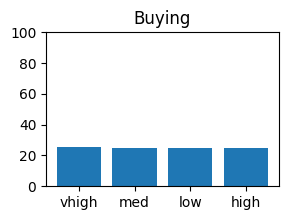

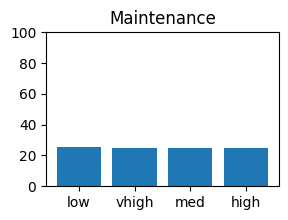

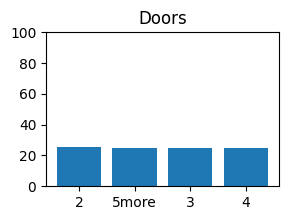

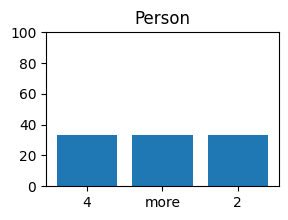

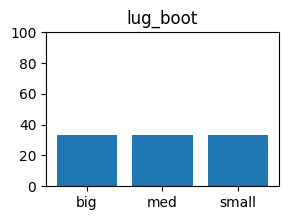

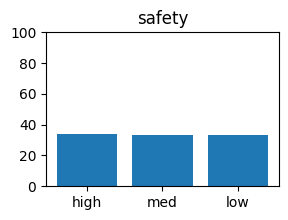

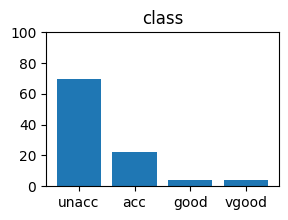

In [6]:
for col in df.columns:
    counts = df[col].value_counts(normalize=True)*100 # quiero usar valores normalizados para ver mejor la diferencia
    #print(f"\n{counts.round(2).to_string()}")

    plt.figure(figsize=(3, 2))
    plt.bar(counts.index, counts.values)
    plt.title(col)
    plt.ylim(0, 100)
    plt.show()

Estas visualizaciones nos indican que no existen valores atípicos dentro de los valores de entrada, pero si podemos apreciar que existen pocos casos donde estos datos obtienen una clase diferente a inaceptable (unacc).

#### Fase 5 - Análisis de correlación entre variables
Primero vamos a generar la matriz de correlación para poder visualizar como se influencian entre sí los datos.

Matriz de correlación:

             Buying  Maintenance  Doors  Person  lug_boot  safety  class
Buying         1.00         0.01  -0.01   -0.00     -0.00   -0.00  -0.29
Maintenance    0.01         1.00  -0.00   -0.01     -0.00   -0.01  -0.25
Doors         -0.01        -0.00   1.00   -0.00     -0.00   -0.00   0.07
Person        -0.00        -0.01  -0.00    1.00      0.00    0.01   0.34
lug_boot      -0.00        -0.00  -0.00    0.00      1.00   -0.00   0.16
safety        -0.00        -0.01  -0.00    0.01     -0.00    1.00   0.44
class         -0.29        -0.25   0.07    0.34      0.16    0.44   1.00


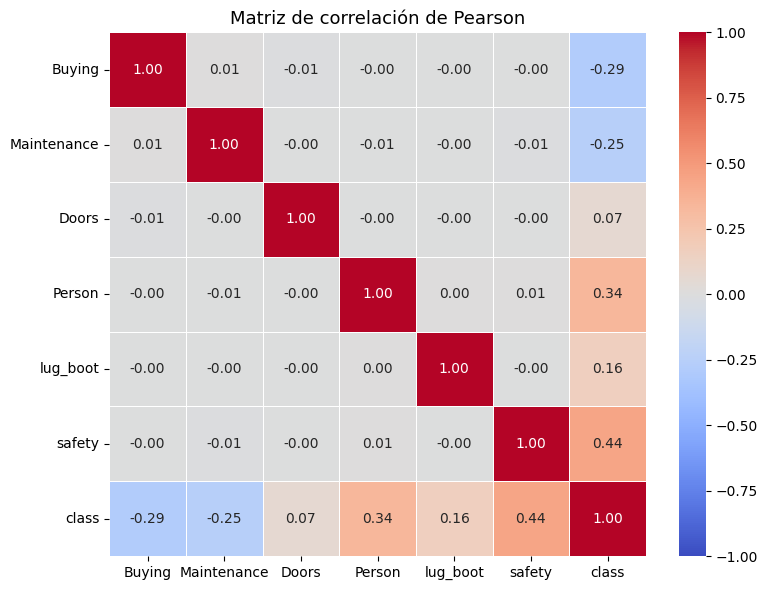

In [7]:
# Definimos el orden lógico de cada atributo
from sklearn.preprocessing import OrdinalEncoder

ordenes = [
    ["low", "med", "high", "vhigh"],  # Buying
    ["low", "med", "high", "vhigh"],  # Maintenance
    ["2", "3", "4", "5more"],         # Doors
    ["2", "4", "more"],               # Person
    ["small", "med", "big"],          # lug_boot
    ["low", "med", "high"],           # safety
    ["unacc", "acc", "good", "vgood"] # class
]

oe = OrdinalEncoder(categories = ordenes)
df_encoded = pd.DataFrame(
    oe.fit_transform(df),
    columns = df.columns
)

# Matriz de correlación
correlacion = df_encoded.corr()

print("Matriz de correlación:\n")
print(correlacion.round(2).to_string())

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title("Matriz de correlación de Pearson", fontsize=13)
plt.tight_layout()
plt.show()

Gracias a la matriz de correlación podemos observar como la clase del vehículo (su aceptación) empeora cuando el precio es altamente elevado (buying es vhigh) y/o requiere mucho manteniemiento (maintenance es vhigh). Lo contrario sucede cuanto el vehículo tiene mayor número de asientos (person es 5more) y/o es muy seguro (safety es high). Cabe destacar que el tamaño del maletero y el númro de puertas afecta positivamente, aunque en menor medidad que el número de asientos, a la clase final del vehículo.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [8]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding
# 1º) lidiamos con los nulo reemplazandolos por el valor deseado, ya sea mean o 'desconocido'
# En nuestro caso no tenemos nulos
# 2º) Realizamos la selección de variables y eliminamos las que consideremos innecesarias
# En nuestro caso todos los datos influyen en la clase final
# Podríamos quizá deshacernos de doors, ya que tiene poca influencia
# df = df.drop("Doors", axis=1)
df.head()

,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [9]:
# 3º) Seleccionadas las variables con las que nos quedamos tendremos que ver si hay que hacer alguna transformación
# En nuestro caso convertir valores string a numéricos.
# Aprovecho el df_encoded que contiene los valores asignados con OrdinalEncoder
df_encoded = df_encoded.astype(int)

print(f"\nBuying: {df['Buying'].unique()}\nBuying_encoded: {df_encoded['Buying'].unique()}")
print(f"Maintenance: {df['Maintenance'].unique()}\nMaintenance_encoded: {df_encoded['Maintenance'].unique()}")
print(f"Doors: {df['Doors'].unique()}\nDoors_encoded: {df_encoded['Doors'].unique()}")
print(f"Person: {df['Person'].unique()}\nPerson_encoded: {df_encoded['Person'].unique()}")
print(f"lug_boot: {df['lug_boot'].unique()}\nlug_boot_encoded: {df_encoded['lug_boot'].unique()}")
print(f"safety: {df['safety'].unique()}\nsafety_encoded: {df_encoded['safety'].unique()}")
print(f"class: {df['class'].unique()}\nclass_encoded: {df_encoded['class'].unique()}")

df_encoded.head()


Buying: ['vhigh' 'high' 'med' 'low']
Buying_encoded: [3 2 1 0]
Maintenance: ['vhigh' 'high' 'med' 'low']
Maintenance_encoded: [3 2 1 0]
Doors: ['2' '3' '4' '5more']
Doors_encoded: [0 1 2 3]
Person: ['2' '4' 'more']
Person_encoded: [0 1 2]
lug_boot: ['small' 'med' 'big']
lug_boot_encoded: [0 1 2]
safety: ['low' 'med' 'high']
safety_encoded: [0 1 2]
class: ['unacc' 'acc' 'vgood' 'good']
class_encoded: [0 1 3 2]


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0


## División del dataset en datos de entrenamiento y datos de test 

In [10]:
from sklearn.model_selection import train_test_split

# 1º) separo la clase objetivo del resto del dataset
X, y = df_encoded.drop('class', axis=1), df['class']
# print(x.head(10))
# print("\n",y.head(10))

# 2º) Configuro el entrenamiento y test con sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Ajuste de los modelos de clasificación propuestos

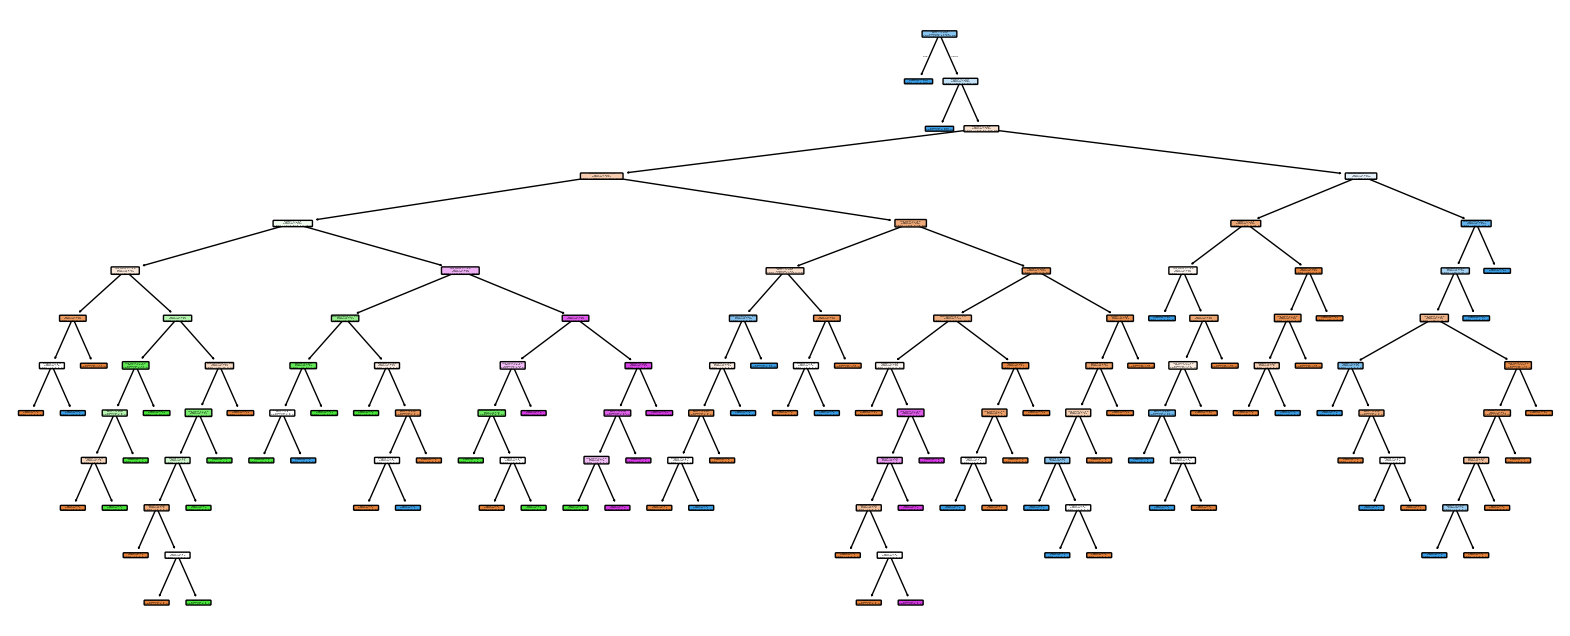

In [11]:
#Código de ajuste del modelo de clasificación 1 (árbol de decisión)

# Librerías necesarias para aplicar el algoritmo de árboles de decisión y posteriormente evaluarlo
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 1º) Construimos el modelo para el clasificador de árbol de decisión.
clf_ad = DecisionTreeClassifier()

# 2º) Entrenamos el modelo con los datos de entrenamiento
clf_ad.fit(X_train, y_train)

# 3º) Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf_ad.predict(X_test)

# Visualizamos el resultado del árbol de decisión
plt.figure(figsize=(20, 8))
plot_tree(clf_ad, filled=True, feature_names=X.columns, rounded=True)
plt.show()

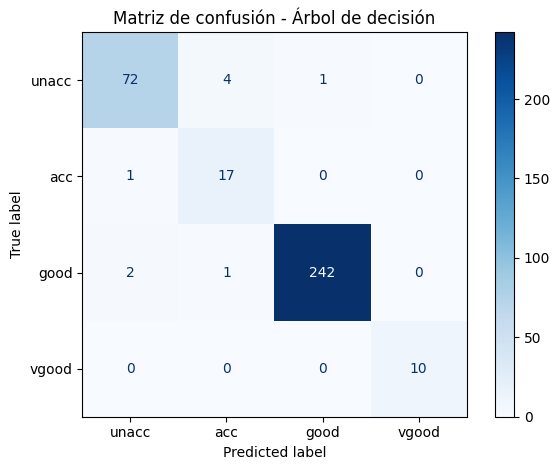

Precisión del modelo: 0.97
Instancias clasificadas correctamente: 341
Instancias clasificadas incorrectamente: 9

TPR unacc: 0.94
TPR acc: 0.94
TPR good: 0.99
TPR vgood: 1.00

FPR unacc: 0.01
FPR acc: 0.02
FPR good: 0.00
FPR vgood: 0.00


In [12]:
#Código para mostrar la evaluación del modelo de clasificación 1 (árbol de decisiones)

# Visualizamos la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

etiquetas = ["unacc", "acc", "good", "vgood"]

cm_ad = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ad, display_labels=etiquetas)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Árbol de decisión")
plt.tight_layout()
plt.show()

# Evaluamos la precisión del modelo
reporte_ad = classification_report(y_test, y_pred, output_dict=True) # Me guardo el reporte y accuracy para la comparación de los modelos
rep_ad = classification_report(y_test, y_pred)
accuracy_ad = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy_ad:.2f}')
print(f"Instancias clasificadas correctamente: {cm_ad.diagonal().sum()}")
print(f"Instancias clasificadas incorrectamente: {cm_ad.sum() - cm_ad.diagonal().sum()}")

# True Positive Rate se obtiene de dividir la cantidad de aciertos entre el total de fallos y aciertos
print(f"\nTPR unacc: {cm_ad[0][0] / cm_ad[0].sum():.2f}")
print(f"TPR acc: {cm_ad[1][1] / cm_ad[1].sum():.2f}")
print(f"TPR good: {cm_ad[2][2] / cm_ad[2].sum():.2f}")
print(f"TPR vgood: {cm_ad[3][3] / cm_ad[3].sum():.2f}")

# El cálculo de True Negative Rate es FP / FP + TN -- FP es la columna y TN son los valores que no están ni en la columna ni en la fila
# para más información: https://stackoverflow.com/questions/31324218/scikit-learn-how-to-obtain-true-positive-true-negative-false-positive-and-fal
total = cm_ad.sum()
FP = (cm_ad[:,0].sum() - cm_ad[0][0])
print(f"\nFPR unacc: { FP / (total - FP - cm_ad[0].sum()):.2f}")
FP = (cm_ad[:,1].sum() - cm_ad[1][1])
print(f"FPR acc: { FP / (total - FP - cm_ad[0].sum()):.2f}")
FP = (cm_ad[:,2].sum() - cm_ad[2][2])
print(f"FPR good: {FP / (total - FP - cm_ad[0].sum()):.2f}")
FP = (cm_ad[:,3].sum() - cm_ad[3][3])
print(f"FPR vgood: {FP / (total - FP - cm_ad[0].sum()):.2f}")

### Interpretación de los resultados para el modelo de clasificación 1 (árbol de decisión) 
Podemos observar que el modelo es particularmente bueno en la predicción de casos donde la aceptación del vehículo es buena (good) con casi una tasa de acierto del 100%. Además la precisión (accuracy) del mismo alcanza el 0.94, lo que significa que predice correctamente la aceptación el 94% de las veces. Podemos decir que este modelo cumple con nuestro objetivo sin problema.

In [13]:
#Código de ajuste del modelo de clasificación 2 (Random Forest)

from sklearn.ensemble import RandomForestClassifier

# Construimos el modelo para el clasificador de Random Forest con los parámetros establecidos por defecto(en este caso 100)
clf_rf = RandomForestClassifier(random_state=100)

# Entrenamos el modelo a partir de los datos de entrenamiento
clf_rf.fit(X_train, y_train)

#  Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf_rf.predict(X_test)

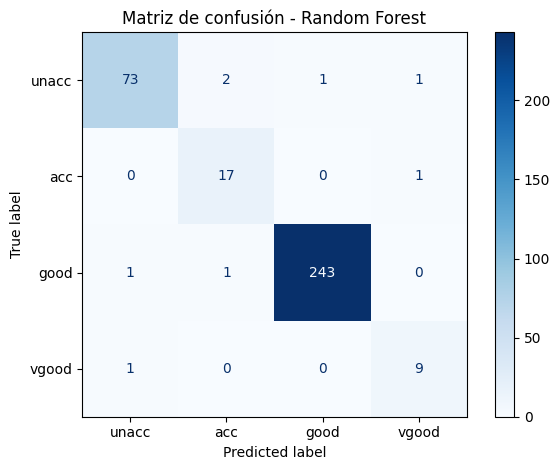

Precisión del modelo: 0.98
Instancias clasificadas correctamente: 342
Instancias clasificadas incorrectamente: 8

TPR unacc: 0.95
TPR acc: 0.94
TPR good: 0.99
TPR vgood: 0.90

FPR unacc: 0.01
FPR acc: 0.01
FPR good: 0.00
FPR vgood: 0.01


In [14]:
#Código  para mostrarla evaluación del modelo de clasificación 2 (Random Forest)

# Visualizamos la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

etiquetas = ["unacc", "acc", "good", "vgood"]

cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=etiquetas)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

# Evaluamos la precisión del modelo
reporte_rf = classification_report(y_test, y_pred, output_dict=True) # Me guardo el reporte y accuracy para la comparación de los modelos
rep_rf = classification_report(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy_rf:.2f}')
print(f"Instancias clasificadas correctamente: {cm_rf.diagonal().sum()}")
print(f"Instancias clasificadas incorrectamente: {cm_rf.sum() - cm_rf.diagonal().sum()}")

# True Positive Rate se obtiene de dividir la cantidad de aciertos entre el total de fallos y aciertos
print(f"\nTPR unacc: {cm_rf[0][0] / cm_rf[0].sum():.2f}")
print(f"TPR acc: {cm_rf[1][1] / cm_rf[1].sum():.2f}")
print(f"TPR good: {cm_rf[2][2] / cm_rf[2].sum():.2f}")
print(f"TPR vgood: {cm_rf[3][3] / cm_rf[3].sum():.2f}")

# El cálculo de True Negative Rate es FP / FP + TN -- FP es la columna y TN son los valores que no están ni en la columna ni en la fila
# para más información: https://stackoverflow.com/questions/31324218/scikit-learn-how-to-obtain-true-positive-true-negative-false-positive-and-fal
total = cm_rf.sum()
FP = (cm_rf[:,0].sum() - cm_rf[0][0])
print(f"\nFPR unacc: { FP / (total - FP - cm_rf[0].sum()):.2f}")
FP = (cm_rf[:,1].sum() - cm_rf[1][1])
print(f"FPR acc: { FP / (total - FP - cm_rf[0].sum()):.2f}")
FP = (cm_rf[:,2].sum() - cm_rf[2][2])
print(f"FPR good: {FP / (total - FP - cm_rf[0].sum()):.2f}")
FP = (cm_rf[:,3].sum() - cm_rf[3][3])
print(f"FPR vgood: {FP / (total - FP - cm_rf[0].sum()):.2f}")

### Interpretación de resultados del modelo de clasificación 2 (Random Forest)
Este modelo tiene una gran precisión para predecir cuando la aceptación va a ser inaceptable (unacc) y buena (good), pero sacrifica los otros casos. Esto parece deberse a la falta de datos de entrenamiento para los casos en los que el vehículo es aceptable (acc) y muy bueno (vgood). Aun así evita marcar falsos positivos y logra una precisión (accuracy) del 93%.

## Comparación del desempeño de modelos

In [15]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla
print("Reporte de clasificación del modelo 1 (árbol de decisión):")
print(rep_ad)
print("Reporte de clasificación del modelo 2 (random forest):")
print(rep_rf)

Reporte de clasificación del modelo 1 (árbol de decisión):
              precision    recall  f1-score   support

         acc       0.96      0.94      0.95        77
        good       0.77      0.94      0.85        18
       unacc       1.00      0.99      0.99       245
       vgood       1.00      1.00      1.00        10

    accuracy                           0.97       350
   macro avg       0.93      0.97      0.95       350
weighted avg       0.98      0.97      0.97       350

Reporte de clasificación del modelo 2 (random forest):
              precision    recall  f1-score   support

         acc       0.97      0.95      0.96        77
        good       0.85      0.94      0.89        18
       unacc       1.00      0.99      0.99       245
       vgood       0.82      0.90      0.86        10

    accuracy                           0.98       350
   macro avg       0.91      0.95      0.93       350
weighted avg       0.98      0.98      0.98       350



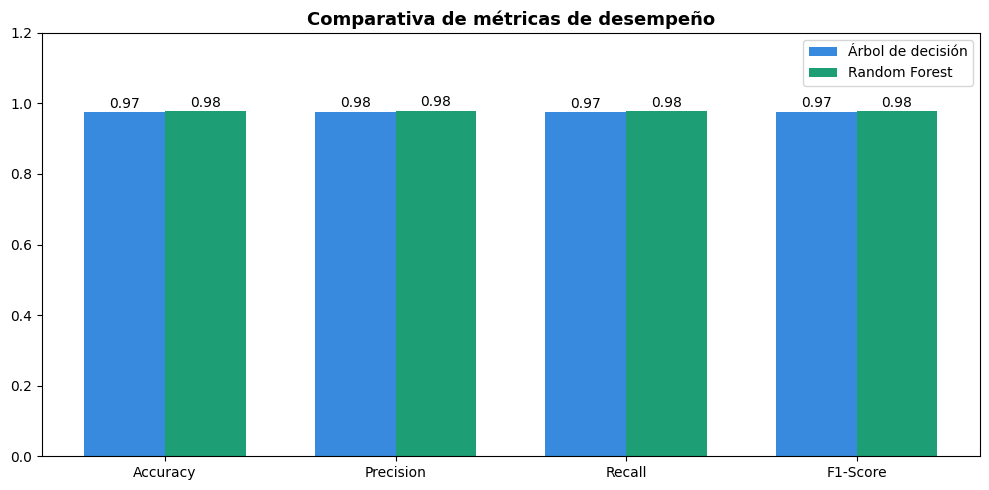

In [16]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica

metricas = ["Accuracy", "Precision", "Recall", "F1-Score"]
valores_ad = [
    accuracy_ad,
    reporte_ad["weighted avg"]["precision"],
    reporte_ad["weighted avg"]["recall"],
    reporte_ad["weighted avg"]["f1-score"]
]
valores_rf = [
    accuracy_rf,
    reporte_rf["weighted avg"]["precision"],
    reporte_rf["weighted avg"]["recall"],
    reporte_rf["weighted avg"]["f1-score"]
]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

barras_ad = ax.bar(x - width/2, valores_ad, width, 
                    label="Árbol de decisión", color="#378ADD")
barras_rf = ax.bar(x + width/2, valores_rf, width, 
                    label="Random Forest", color="#1D9E75")

# Etiquetas encima de cada barra
for barra in barras_ad:
    ax.text(barra.get_x() + barra.get_width()/2, 
            barra.get_height() + 0.005,
            f"{barra.get_height():.2f}", 
            ha="center", va="bottom", fontsize=10)

for barra in barras_rf:
    ax.text(barra.get_x() + barra.get_width()/2, 
            barra.get_height() + 0.005,
            f"{barra.get_height():.2f}", 
            ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.2)
ax.set_title("Comparativa de métricas de desempeño", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

El desempeño de ambos modelos parece estar muy equiparado, siendo random forest ligeramente mejor ya que en lgráfica podemos ver como supera al árbol de decisión tanto en accuracy como en recall. Los dos modelos que hemos utilizado han alcanzado casi un 100% de precisión y recall, esto implica que ambos cumplen con las expectativas del problema.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

El arbol de decisión que conforma el primer modelo puede ser refinado utilizando poda o incluso limitando la profundidad del árbol generado por el algoritmo, para evitar overfitting. Esto mejoraría su desempeño y haría al modelo más ligero sacrificando, quizas, su precisión (accuracy). 

Para la mejora del segundo modelo, necesitamos una base de datos más diversa, no necesariamente más grande o compleja, que permita al modelo adquirir mayor conocimiento para casos diversos. Repitiendo el entrenamiento con esta nueva base de datos, mejoraría la predicción de verdaderos positivos para los casos donde la precisión es, actualmente, menor.